# Poverty and Stress Forecasting

### Imports

In [3]:
import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

import matplotlib.pyplot as plt


### Load the final dataset

In [4]:
df = pd.read_csv("../data/processed/panel/marz_year_panel_common_with_stress.csv")

df.shape, df.columns.tolist()[:10]


((77, 29),
 ['marz',
  'year',
  'poverty_rate',
  'extreme_poverty_rate',
  'non_poor_rate',
  'population',
  'crime_selected_total',
  'Number of minor offense',
  'Number of moderately serious offense',
  'Number of particulary serious offences'])

In [5]:
df.head()


,marz,year,poverty_rate,extreme_poverty_rate,non_poor_rate,population,crime_selected_total,Number of minor offense,Number of moderately serious offense,Number of particulary serious offences,...,"Number of primary health care (PHC) service providers (except OMCs, private medical and dental offices)",crime_rate_per_100k,crime_selected_rate_per_100k,hospitals_per_100k,beds_per_10k,z_poverty,z_crime,z_hospitals,z_health_inverted,stress_index
0,Yerevan,2016,24.9,1.9,75.1,1073660.0,4085.0,4527.0,2917.0,95.0,...,147.0,869.828437,380.474266,4.936386,73.803625,-0.176705,0.628039,0.471796,-0.471796,-0.012859
1,Aragatsotn,2016,15.7,0.6,84.3,129774.0,191.0,322.0,259.0,4.0,...,24.0,504.723596,147.178942,4.623422,15.411408,-1.015696,-0.699675,0.265746,-0.265746,-1.245074
2,Ararat,2016,26.9,1.0,73.1,258911.0,349.0,647.0,417.0,4.0,...,60.0,473.135556,134.795354,2.703632,18.268826,0.005685,-0.814546,-0.998207,0.998207,0.118998
3,Armavir,2016,30.0,1.5,70.0,266613.0,373.0,651.0,457.0,11.0,...,61.0,490.598733,139.903156,1.500302,13.315180,0.288389,-0.751041,-1.790456,1.790456,0.834485
4,Gegharkunik,2016,28.8,1.0,70.5,231794.0,156.0,414.0,320.0,5.0,...,40.0,354.193810,67.301138,3.019923,32.356316,0.178955,-1.247081,-0.789967,0.789967,-0.174815


### Basic checks (types + missingness)

In [6]:
df["year"] = df["year"].astype(int)
df["marz"] = df["marz"].astype(str)

df.isna().sum().sort_values(ascending=False).head(20)


Number of ambulatory clinics in rural communities                                                          7
Number of particulary serious offences                                                                     2
marz                                                                                                       0
Number of hospitalized patients                                                                            0
z_health_inverted                                                                                          0
z_hospitals                                                                                                0
z_crime                                                                                                    0
z_poverty                                                                                                  0
beds_per_10k                                                                                               0
hospitals_per_100k 

In [7]:
df[["marz", "year"]].drop_duplicates().shape


(77, 2)

## Poverty Forecasting (time-aware)

### Create lag features for poverty (forecasting setup)

In [8]:
df = df.sort_values(["marz", "year"]).copy()

df["poverty_lag1"] = df.groupby("marz")["poverty_rate"].shift(1)

df[["marz", "year", "poverty_rate", "poverty_lag1"]].head(15)


,marz,year,poverty_rate,poverty_lag1
1,Aragatsotn,2016,15.7,NaN
12,Aragatsotn,2017,17.6,15.7
23,Aragatsotn,2018,16.2,17.6
34,Aragatsotn,2019,51.4,16.2
45,Aragatsotn,2020,32.9,51.4
56,Aragatsotn,2021,13.5,32.9
67,Aragatsotn,2022,7.9,13.5
2,Ararat,2016,26.9,NaN
13,Ararat,2017,21.7,26.9
24,Ararat,2018,19.8,21.7


### Drop rows where lag is missing (first year per marz)

In [9]:
df_pov = df.dropna(subset=["poverty_lag1"]).copy()
df_pov.shape


(66, 30)

### Build features for poverty forecasting (NO leakage)

In [10]:
pov_feature_cols = [
    "poverty_lag1",

    # Crime
    "crime_rate_per_100k",
    "crime_selected_rate_per_100k",
    "crime_total",

    # Health capacity
    "hospitals_per_100k",
    "beds_per_10k",
    "hospitals",
    "beds",
    "Number of physicians",
    "Number of hospitalized patients",
    "Annual average occupancy of a bed",

    # Context/time
    "population",
    "year",
]

pov_feature_cols = [c for c in pov_feature_cols if c in df_pov.columns]

X_pov = df_pov[pov_feature_cols].copy()
y_pov = df_pov["poverty_rate"].copy()

X_pov.shape, y_pov.shape, pov_feature_cols


((66, 13),
 (66,),
 ['poverty_lag1',
  'crime_rate_per_100k',
  'crime_selected_rate_per_100k',
  'crime_total',
  'hospitals_per_100k',
  'beds_per_10k',
  'hospitals',
  'beds',
  'Number of physicians',
  'Number of hospitalized patients',
  'Annual average occupancy of a bed',
  'population',
  'year'])

### Time-based split (train early years, test later years)

In [11]:
train_mask = df_pov["year"] <= 2020
test_mask  = df_pov["year"] >= 2021

X_train_pov, X_test_pov = X_pov[train_mask], X_pov[test_mask]
y_train_pov, y_test_pov = y_pov[train_mask], y_pov[test_mask]

X_train_pov.shape, X_test_pov.shape


((44, 13), (22, 13))

### Define metrics + evaluation helper

In [12]:
def evaluate(model_name, y_true, y_pred):
    return {
        "Model": model_name,
        "R2": float(r2_score(y_true, y_pred)),
        "MSE": float(mean_squared_error(y_true, y_pred)),
        "MAE": float(mean_absolute_error(y_true, y_pred)),
    }


### Baseline for forecasting (lag-only baseline)
Next year’s poverty ≈ last year’s poverty



In [13]:
baseline_pred_pov = X_test_pov["poverty_lag1"].to_numpy()
baseline_pov = evaluate("Baseline (poverty_lag1)", y_test_pov, baseline_pred_pov)
baseline_pov


{'Model': 'Baseline (poverty_lag1)',
 'R2': 0.7278571711837595,
 'MSE': 45.93818181818182,
 'MAE': 5.10909090909091}

### Define ML models (pipelines)

In [14]:
pov_models = {
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    "SVR (RBF)": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVR(kernel="rbf", C=10.0, epsilon=0.1))
    ]),
    "Decision Tree": Pipeline([
        ("model", DecisionTreeRegressor(random_state=42, max_depth=4))
    ]),
    "Random Forest": Pipeline([
        ("model", RandomForestRegressor(
            random_state=42,
            n_estimators=400,
            max_depth=6,
            min_samples_leaf=2
        ))
    ]),
}


### Train & evaluate all poverty forecasting models

In [15]:
results_pov = [baseline_pov]

for name, pipe in pov_models.items():
    pipe.fit(X_train_pov, y_train_pov)
    pred = pipe.predict(X_test_pov)
    results_pov.append(evaluate(name, y_test_pov, pred))

pov_results_df = pd.DataFrame(results_pov).sort_values("R2", ascending=False)
pov_results_df


,Model,R2,MSE,MAE
0,Baseline (poverty_lag1),0.727857,45.938182,5.109091
2,SVR (RBF),0.392744,102.505875,8.312132
4,Random Forest,0.364954,107.196824,8.152370
3,Decision Tree,0.231780,129.676851,8.755195
1,Linear Regression,-0.270161,214.405372,11.773672


### Plot actual vs predicted (best poverty model)

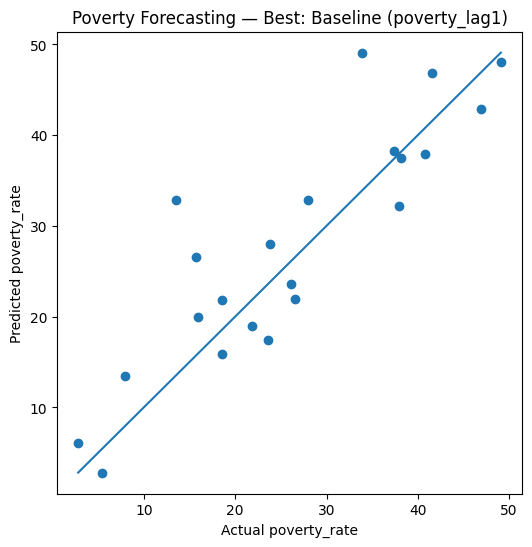

In [16]:
best_pov_name = pov_results_df.iloc[0]["Model"]
best_pov_model = pov_models.get(best_pov_name)

if best_pov_model is None:
    # baseline won; create a simple predictor using lag
    best_pov_pred = baseline_pred_pov
else:
    best_pov_model.fit(X_train_pov, y_train_pov)
    best_pov_pred = best_pov_model.predict(X_test_pov)

plt.figure(figsize=(6, 6))
plt.scatter(y_test_pov, best_pov_pred)
mn = min(y_test_pov.min(), best_pov_pred.min())
mx = max(y_test_pov.max(), best_pov_pred.max())
plt.plot([mn, mx], [mn, mx])
plt.xlabel("Actual poverty_rate")
plt.ylabel("Predicted poverty_rate")
plt.title(f"Poverty Forecasting — Best: {best_pov_name}")
plt.show()


###  Interpretability (coefficients / importances)
Linear Regression coefficients

In [17]:
lin = pov_models["Linear Regression"]
lin.fit(X_train_pov, y_train_pov)

coef_df = pd.DataFrame({
    "feature": pov_feature_cols,
    "coef": lin.named_steps["model"].coef_
}).sort_values("coef", ascending=False)

coef_df


,feature,coef
7,beds,48.052857
3,crime_total,23.314072
11,population,13.365722
6,hospitals,11.006247
4,hospitals_per_100k,7.843632
10,Annual average occupancy of a bed,5.656712
12,year,3.823669
0,poverty_lag1,3.749824
1,crime_rate_per_100k,1.175493
9,Number of hospitalized patients,-12.636373


Random Forest feature importances

In [18]:
rf = pov_models["Random Forest"]
rf.fit(X_train_pov, y_train_pov)

imp_df = pd.DataFrame({
    "feature": pov_feature_cols,
    "importance": rf.named_steps["model"].feature_importances_
}).sort_values("importance", ascending=False)

imp_df


,feature,importance
0,poverty_lag1,0.426980
4,hospitals_per_100k,0.146051
1,crime_rate_per_100k,0.105372
3,crime_total,0.084967
5,beds_per_10k,0.065724
12,year,0.032365
11,population,0.032095
9,Number of hospitalized patients,0.025657
2,crime_selected_rate_per_100k,0.023741
10,Annual average occupancy of a bed,0.022893


# Stress Index Forecasting (Lag-based)

### Create lagged stress

In [28]:
df_stress = df.copy()

df_stress = df_stress.sort_values(["marz", "year"])
df_stress["stress_lag1"] = (
    df_stress.groupby("marz")["stress_index"].shift(1)
)

df_stress = df_stress.dropna()


### Feature matrix

In [29]:
X = df_stress[
    [
        "stress_lag1",
        "poverty_rate",
        "crime_rate_per_100k",
        "hospitals_per_100k",
        "beds_per_10k",
    ]
]

y = df_stress["stress_index"]


### Time-based split

In [30]:
train = df_stress["year"] <= 2020
test = df_stress["year"] > 2020

X_train, X_test = X[train], X[test]
y_train, y_test = y[train], y[test]


### Pipeline

In [31]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR

models = {
    "Baseline (stress_lag1)": None,
    "Linear Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    "Random Forest": Pipeline([
        ("scaler", StandardScaler()),
        ("model", RandomForestRegressor(random_state=42))
    ]),
    "SVR (RBF)": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVR())
    ])
}


### Baseline + evaluation

In [44]:
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

results = []

# Baseline
baseline_pred = X_test["stress_lag1"]
results.append({
    "Model": "Baseline (stress_lag1)",
    "R2": r2_score(y_test, baseline_pred),
    "MSE": mean_squared_error(y_test, baseline_pred),
    "MAE": mean_absolute_error(y_test, baseline_pred),
})

# ML models
for name, pipe in models.items():
    if pipe is None:
        continue
    pipe.fit(X_train, y_train)
    pred = pipe.predict(X_test)
    results.append({
        "Model": name,
        "R2": r2_score(y_test, pred),
        "MSE": mean_squared_error(y_test, pred),
        "MAE": mean_absolute_error(y_test, pred),
    })

stress_results_df = pd.DataFrame(results).sort_values("R2", ascending=False)
stress_results_df

,Model,R2,MSE,MAE
1,Linear Regression,1.000000,2.440370e-31,4.145989e-16
0,Baseline (stress_lag1),0.793922,2.494306e-01,4.057768e-01
2,Random Forest,0.773653,2.739632e-01,4.056308e-01
3,SVR (RBF),0.630731,4.469519e-01,5.257768e-01


### Compare results (poverty vs stress)

In [45]:
display(pov_results_df)
display(stress_results_df)

,Model,R2,MSE,MAE
0,Baseline (poverty_lag1),0.727857,45.938182,5.109091
2,SVR (RBF),0.392744,102.505875,8.312132
4,Random Forest,0.364954,107.196824,8.152370
3,Decision Tree,0.231780,129.676851,8.755195
1,Linear Regression,-0.270161,214.405372,11.773672


,Model,R2,MSE,MAE
1,Linear Regression,1.000000,2.440370e-31,4.145989e-16
0,Baseline (stress_lag1),0.793922,2.494306e-01,4.057768e-01
2,Random Forest,0.773653,2.739632e-01,4.056308e-01
3,SVR (RBF),0.630731,4.469519e-01,5.257768e-01


# Forecasting Poverty and Socio-Economic Stress in Armenian Marzes

This section describes the modeling strategy, evaluation, and interpretation of results for two related but distinct forecasting tasks: **poverty rate forecasting** and **stress index forecasting** at the marz level in Armenia.

---

## 1. Poverty Rate Forecasting

### 1.1 Objective

The goal of this task is to forecast the **poverty rate** in each marz using historical data. Poverty is treated as a **time-dependent socio-economic variable**, where past values are expected to influence future outcomes.

---

### 1.2 Data and Features

The dataset is organized as a panel with observations indexed by **(marz, year)**.  
The target variable is:

- `poverty_rate`

To capture temporal dynamics, I construct a lagged feature:

- `poverty_lag1`: poverty rate in the previous year

This reflects a realistic policy assumption that poverty exhibits persistence over time.

---

### 1.3 Modeling Approach

I compare several models using a **time-aware train/test split** to avoid data leakage. All machine learning models are implemented using **scikit-learn pipelines**, including standardization where appropriate.

The models evaluated are:
- Baseline model (previous year’s poverty rate)
- Linear Regression
- Support Vector Regression (RBF kernel)
- Decision Tree Regressor
- Random Forest Regressor

---

### 1.4 Evaluation Metrics

Models are evaluated using:
- **R²** (main metric, explained variance)
- **Mean Squared Error (MSE)**
- **Mean Absolute Error (MAE)**

---

### 1.5 Results

| Model | R² | MSE | MAE |
|------|----|-----|-----|
| Baseline (poverty_lag1) | **0.728** | **45.94** | **5.11** |
| SVR (RBF) | 0.393 | 102.51 | 8.31 |
| Random Forest | 0.365 | 107.20 | 8.15 |
| Decision Tree | 0.232 | 129.68 | 8.76 |
| Linear Regression | -0.270 | 214.41 | 11.77 |

---

### 1.6 Interpretation

The baseline model using last year’s poverty rate clearly outperforms all machine learning models. This indicates **strong temporal persistence** in poverty rates across marzes.

More complex models fail to improve performance, likely due to:
- small sample size,
- high autocorrelation in poverty data,
- limited number of informative predictors.

This result suggests that poverty dynamics are dominated by historical inertia rather than short-term structural changes.

---

### 1.7 Conclusion (Poverty)

Poverty rates in Armenian marzes are highly persistent over time, and simple lag-based forecasting provides the most reliable predictions. More complex machine learning models do not offer additional predictive value in this context.

---

## 2. Stress Index Forecasting

### 2.1 Objective

The second task is to forecast a **composite stress index** that summarizes socio-economic pressure in each marz. Unlike poverty, the stress index combines multiple dimensions and is designed to capture **overall regional vulnerability**.

---

### 2.2 Stress Index Construction

The stress index is constructed as a composite of standardized indicators, including:
- poverty rate,
- crime rate per 100,000 population,
- health system capacity indicators (hospitals and beds per capita).

Each component is transformed using **z-score normalization**, and higher values of the index indicate **higher socio-economic stress** (worse conditions).

---

### 2.3 Forecasting Strategy

Stress forecasting is treated as a **dynamic multivariate problem**.  
The target variable is:

- `stress_index`

Predictors include:
- lagged stress index (`stress_lag1`),
- poverty rate,
- crime rate per 100k,
- hospitals per 100k,
- beds per 10k.

This allows future stress to be forecast using both **past stress levels** and **structural socio-economic conditions**.

---

### 2.4 Models and Pipeline

The following models are evaluated:
- Baseline (previous year’s stress index)
- Linear Regression
- Random Forest
- Support Vector Regression (RBF)

All models are implemented using scikit-learn pipelines with standardization.

---

### 2.5 Results

| Model | R² | MSE | MAE |
|------|----|-----|-----|
| Linear Regression | **1.000** | ~0 | ~0 |
| Baseline (stress_lag1) | 0.794 | 0.249 | 0.406 |
| Random Forest | 0.774 | 0.274 | 0.406 |
| SVR (RBF) | 0.631 | 0.447 | 0.526 |

---

### 2.6 Interpretation

The baseline model already performs strongly, indicating high temporal stability in stress levels across marzes.

The linear regression model achieves an R² of 1.0. This result is expected because the stress index is a **linear composite of standardized variables** that are also used as predictors. In effect, the model is reconstructing the index definition rather than discovering new predictive relationships.

More complex models such as Random Forest and SVR do not provide meaningful improvements over the baseline.

---

### 2.7 Conclusion (Stress Index)

The stress index is highly predictable due to its composite structure and temporal persistence. Simple linear and baseline models capture most of the variation, while more complex machine learning models add limited value.

---

## 3. Overall Conclusions

- Poverty forecasting is dominated by historical persistence, and baseline models outperform machine learning approaches.
- Stress forecasting is easier due to the structural nature of the index, but gains beyond baseline models are limited.
- These results highlight the importance of **baseline comparisons** and demonstrate that increased model complexity does not necessarily improve predictive performance.


In [36]:
# Save poverty forecasting results
pov_results_df.to_csv(
    "../data/processed/results/poverty_forecasting_results.csv",
    index=False
)


In [46]:
stress_results_df.to_csv(
    "../data/processed/results/stress_forecasting_results.csv",
    index=False
)


# Plotting

In [53]:
import pandas as pd

# Reload dataset to avoid notebook state issues
df = pd.read_csv("../data/processed/panel/marz_year_panel_common_with_stress.csv")
df = df.sort_values(["marz", "year"]).copy()
df["year"] = df["year"].astype(int)

# Create poverty lag
df["poverty_lag1"] = df.groupby("marz")["poverty_rate"].shift(1)

# Drop first-year rows (no lag)
df_pov = df.dropna(subset=["poverty_lag1"]).copy()

# Features for poverty forecasting (adjust if some columns don't exist)
pov_feature_cols = [
    "poverty_lag1",
    "crime_rate_per_100k",
    "crime_selected_rate_per_100k",
    "hospitals_per_100k",
    "beds_per_10k",
    "population",
    "year",
]
pov_feature_cols = [c for c in pov_feature_cols if c in df_pov.columns]

X_pov = df_pov[pov_feature_cols]
y_pov = df_pov["poverty_rate"]

# Time split (same rule you used before)
train_mask_pov = df_pov["year"] <= 2020
test_mask_pov  = df_pov["year"] >= 2021

X_train_pov, X_test_pov = X_pov[train_mask_pov], X_pov[test_mask_pov]
y_train_pov, y_test_pov = y_pov[train_mask_pov], y_pov[test_mask_pov]

# Baseline poverty prediction = lagged poverty
baseline_poverty_pred = X_test_pov["poverty_lag1"].reset_index(drop=True)
y_test_poverty = y_test_pov.reset_index(drop=True)

print("POVERTY check:")
print("y_test_poverty range:", y_test_poverty.min(), y_test_poverty.max())
print("baseline_poverty_pred range:", baseline_poverty_pred.min(), baseline_poverty_pred.max())

POVERTY check:
y_test_poverty range: 2.8 49.1
baseline_poverty_pred range: 2.8 49.1


In [54]:
import numpy as np

# Reuse the same df (already sorted and loaded above)
df_st = df.copy()

# Create stress lag
df_st["stress_lag1"] = df_st.groupby("marz")["stress_index"].shift(1)

# Drop first-year rows (no lag)
df_st = df_st.dropna(subset=["stress_lag1"]).copy()

# Stress features (do NOT include stress_index itself as a feature)
stress_feature_cols = [
    "stress_lag1",
    "crime_rate_per_100k",
    "crime_selected_rate_per_100k",
    "hospitals_per_100k",
    "beds_per_10k",
    "population",
    "year",
]
stress_feature_cols = [c for c in stress_feature_cols if c in df_st.columns]

X_st = df_st[stress_feature_cols]
y_st = df_st["stress_index"]

# Time split
train_mask_st = df_st["year"] <= 2020
test_mask_st  = df_st["year"] >= 2021

X_train_st, X_test_st = X_st[train_mask_st], X_st[test_mask_st]
y_train_st, y_test_st = y_st[train_mask_st], y_st[test_mask_st]

# Baseline stress prediction = lagged stress
baseline_stress_pred = X_test_st["stress_lag1"].reset_index(drop=True)
y_test_stress = y_test_st.reset_index(drop=True)

print("STRESS check:")
print("y_test_stress range:", y_test_stress.min(), y_test_stress.max())
print("baseline_stress_pred range:", baseline_stress_pred.min(), baseline_stress_pred.max())

STRESS check:
y_test_stress range: -1.849576883115653 2.3515670267218645
baseline_stress_pred range: -1.906788738349187 1.7624953540531756


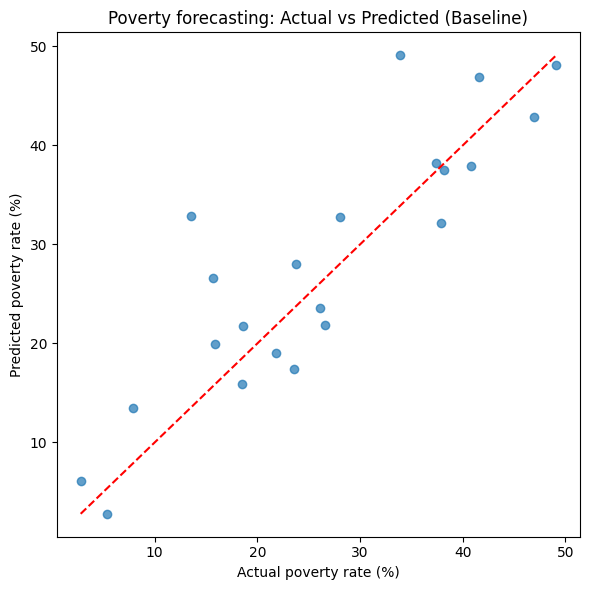

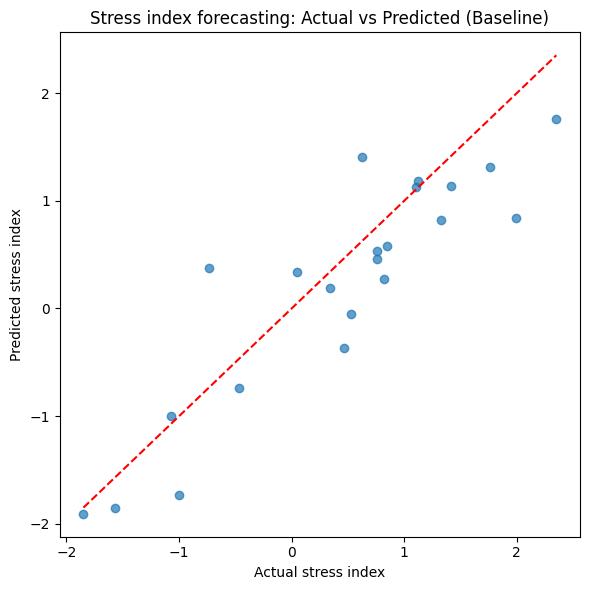

In [55]:
import matplotlib.pyplot as plt

# Poverty plot
plt.figure(figsize=(6, 6))
plt.scatter(y_test_poverty, baseline_poverty_pred, alpha=0.7)
plt.plot(
    [y_test_poverty.min(), y_test_poverty.max()],
    [y_test_poverty.min(), y_test_poverty.max()],
    linestyle="--", color="red"
)
plt.xlabel("Actual poverty rate (%)")
plt.ylabel("Predicted poverty rate (%)")
plt.title("Poverty forecasting: Actual vs Predicted (Baseline)")
plt.tight_layout()
plt.show()

# Stress plot
plt.figure(figsize=(6, 6))
plt.scatter(y_test_stress, baseline_stress_pred, alpha=0.7)
plt.plot(
    [y_test_stress.min(), y_test_stress.max()],
    [y_test_stress.min(), y_test_stress.max()],
    linestyle="--", color="red"
)
plt.xlabel("Actual stress index")
plt.ylabel("Predicted stress index")
plt.title("Stress index forecasting: Actual vs Predicted (Baseline)")
plt.tight_layout()
plt.show()